# Reproducible Visualization of Model Evaluation and Interpretability Analyses

This tutorial provides a **fully reproducible, modular visualization pipeline** for evaluating model performance, robustness, and interpretability in RNA–protein interaction studies. 

## Contents Overview

### 3. icSHAPE reactivities vs thermodynamic predictions
- Metrics: AUC, AUPRC, ACC.
- Key features:
  - Violin + embedded boxplot + median marker.
  - Explicit significance annotations (`geom_signif`).
  - Careful handling of factor levels to ensure consistent statistics.
- Statistical values are preserved exactly as computed from the original data.

```{note}
Please download the pre-computed results from `Figshare` first, and place them in the expected directory.
```

## icSHAPE reactivities vs thermodynamic predictions

```{note}
Create violin plots (with inner boxplot + median point + significance bars)
for ablation study methods:
- icSHAPE
- RNAplfold
- icSHAPE+RNAplfold

Metrics plotted (from Excel sheet "Structure"):
- AUPRC
- ACC

Input Excel requirements

File: S3.xlsx (sheet: "Structure")
- Column 1: model identifier (any name is fine; we will rename it to "model")
- Exactly 3 columns starting with "AUPRC" (e.g., AUPRC_xxx, AUPRC_yyy, AUPRC_zzz)
- Exactly 3 columns starting with "ACC"

Important:
- We match columns using grep("^AUPRC", ...) and grep("^ACC", ...)
- The FIRST, SECOND, THIRD matched columns are mapped to methods in a fixed order:

    - 1st -> icSHAPE+RNAplfold
    - 2nd -> RNAplfold
    - 3rd -> icSHAPE

Output:
- PDF files saved to your specified folder
```

In [ ]:
library(ggplot2)
library(ggsignif)
library(readxl)
library(dplyr)
library(tidyr)


In [ ]:
# Paths -------------------------------------------------------------------
file_path  <- "../ablation&interpretability/S3.xlsx"
sheet_name <- "Structure"

out_dir <- "./"

# Method order on x-axis ---------------------------------------------------
method_levels <- c("icSHAPE", "RNAplfold", "icSHAPE+RNAplfold")

# Fill colors (keep your new version) -------------------------------------
fill_colors <- c(
  icSHAPE             = "#e1795e",
  RNAplfold           = "#FAEBD4",
  `icSHAPE+RNAplfold` = "#FAEBD4"
)

# Significance comparisons -------------------------------------------------
my_comparisons <- list(
  c("icSHAPE", "icSHAPE+RNAplfold"),
  c("icSHAPE", "RNAplfold")
)


In [ ]:
get_metric_cols_and_map <- function(df, metric_prefix) {
  #' Find exactly 3 metric columns and map them to 3 methods in a fixed order.
  #'
  #' Parameters
  #' ----------
  #' df : data.frame
  #'   Data loaded from Excel.
  #' metric_prefix : character
  #'   Column name prefix to match, e.g. "AUPRC" or "ACC".
  #'
  #' Returns
  #' -------
  #' A list with:
  #' - cols: character vector of the 3 matched column names
  #' - method_map: named character vector mapping each column -> method key
  #'
  #' Mapping rule (by matched order):
  #'   1st matched col -> icSHAPE+RNAplfold
  #'   2nd matched col -> RNAplfold
  #'   3rd matched col -> icSHAPE
  
  cols <- grep(paste0("^", metric_prefix), names(df), value = TRUE)
  
  if (length(cols) != 3) {
    stop("Found ", length(cols), " columns starting with '", metric_prefix,
         "'. Expected exactly 3. Please check the header.")
  }
  
  method_map <- setNames(
    c("icSHAPE+RNAplfold", "RNAplfold", "icSHAPE"),
    cols
  )
  
  list(cols = cols, method_map = method_map)
}


In [ ]:
make_long_from_prefix <- function(df, metric_prefix, value_filter = NULL) {
  #' Convert wide table into long format for a metric prefix.
  #'
  #' Parameters
  #' ----------
  #' df : data.frame
  #'   Original Excel data.
  #' metric_prefix : character
  #'   "AUPRC" or "ACC" (used to grep columns).
  #' value_filter : function or NULL
  #'   Optional filter applied to the numeric value column.
  #'   Example for ACC: function(x) x >= 0.54
  #'
  #' Returns
  #' -------
  #' Long tibble with columns:
  #' - model
  #' - Method (factor ordered by method_levels)
  #' - value (numeric)
  
  info <- get_metric_cols_and_map(df, metric_prefix)
  cols <- info$cols
  method_map <- info$method_map
  
  long_df <- df %>%
    rename(model = 1) %>%                    # rename first column to model
    select(model, all_of(cols)) %>%
    pivot_longer(
      cols = all_of(cols),
      names_to = "metric_col",
      values_to = "value",
      values_drop_na = TRUE
    ) %>%
    mutate(
      Method = factor(method_map[metric_col], levels = method_levels)
    )
  
  # Optional numeric filter (e.g., ACC >= 0.54) ----------------------------
  if (!is.null(value_filter)) {
    long_df <- long_df %>% filter(value_filter(value))
  }
  
  long_df
}


In [ ]:
plot_violin_with_signif <- function(long_df, ylab, ylim,
                                    fill_colors, comparisons,
                                    step_increase = 0.08,
                                    textsize = 5,
                                    violin_width = 0.675,
                                    violin_adjust = 1) {
  #' Create a violin plot with boxplot + median point + significance bars.
  #'
  #' Parameters
  #' ----------
  #' long_df : tibble
  #'   Must contain columns: Method (factor) and value (numeric).
  #' ylab : character
  #'   Y-axis label.
  #' ylim : numeric length-2
  #'   Y-axis range shown via coord_cartesian.
  #' fill_colors : named character vector
  #'   Fill colors for each Method level.
  #' comparisons : list
  #'   List of method name pairs for geom_signif.
  #' step_increase : numeric
  #'   Vertical spacing of significance bars.
  #' textsize : numeric
  #'   Text size for significance labels.
  #' violin_width : numeric
  #'   Violin width.
  #' violin_adjust : numeric
  #'   Bandwidth adjustment for violin density.
  
  # Make sure colors cover all methods in data -----------------------------
  methods_in_data <- levels(long_df$Method)
  fill_use <- fill_colors[methods_in_data]
  if (any(is.na(fill_use))) {
    missing <- methods_in_data[is.na(fill_use)]
    stop("fill_colors missing methods: ", paste(missing, collapse = ", "))
  }
  
  p <- ggplot(long_df, aes(x = Method, y = value, fill = Method)) +
    geom_violin(
      trim = TRUE, scale = "area",
      width = violin_width, color = NA,
      adjust = violin_adjust
    ) +
    geom_boxplot(width = 0.05, fill = "black", outlier.shape = NA) +
    geom_point(
      stat = "summary", fun = "median",
      shape = 21, size = 2,
      colour = "black", fill = "white"
    ) +
    coord_cartesian(ylim = ylim) +
    scale_fill_manual(values = fill_use) +
    labs(y = ylab, x = "") +
    theme_minimal() +
    theme(
      legend.position   = "none",
      panel.border      = element_rect(colour = "black", fill = NA, linewidth = 1),
      panel.grid        = element_blank(),
      axis.line         = element_line(linewidth = 0.5),
      axis.ticks        = element_line(linewidth = 0.5),
      axis.ticks.length = unit(0.25, "cm"),
      axis.text.x       = element_text(size = 16, angle = 10, vjust = 1, hjust = 1),
      axis.text.y       = element_text(size = 16),
      axis.title        = element_text(size = 18),
      plot.title        = element_text(size = 20, hjust = 0.5)
    ) +
    geom_signif(
      comparisons      = comparisons,
      step_increase    = step_increase,
      map_signif_level = FALSE,
      textsize         = textsize,
      tip_length       = 0.01
    )
  
  p
}


In [ ]:
df <- read_excel(file_path, sheet = sheet_name)
head(df)

New names:
• `AUC` -> `AUC...2`
• `ACC` -> `ACC...3`
• `AUPRC` -> `AUPRC...4`
• `MCC` -> `MCC...5`
• `` -> `...6`
• `AUC` -> `AUC...8`
• `ACC` -> `ACC...9`
• `AUPRC` -> `AUPRC...10`
• `MCC` -> `MCC...11`
• `` -> `...12`
• `AUC` -> `AUC...14`
• `ACC` -> `ACC...15`
• `AUPRC` -> `AUPRC...16`
• `MCC` -> `MCC...17`


icSHAPE+RNAplfold,AUC...2,ACC...3,AUPRC...4,MCC...5,...6,RNAplfold,AUC...8,ACC...9,AUPRC...10,MCC...11,...12,icSHAPE,AUC...14,ACC...15,AUPRC...16,MCC...17
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
AARS_K562,0.7877,0.7560,0.6951,0.4491,NA,AARS_K562,0.8212,0.7370,0.7451,0.4576,NA,AARS_K562,0.7972,0.7737,0.7224,0.4605
AATF_K562,0.8403,0.7530,0.7386,0.4957,NA,AATF_K562,0.8490,0.8040,0.7640,0.5420,NA,AATF_K562,0.8716,0.8160,0.8000,0.5743
ABCF1_K562,0.8003,0.6233,0.6872,0.3693,NA,ABCF1_K562,0.8175,0.7113,0.7193,0.4399,NA,ABCF1_K562,0.8284,0.7783,0.7340,0.4776
AGGF1_HepG2,0.8418,0.5947,0.7452,0.3734,NA,AGGF1_HepG2,0.8522,0.8027,0.7785,0.5492,NA,AGGF1_HepG2,0.8730,0.8047,0.7976,0.5435
AGGF1_K562,0.8421,0.7723,0.7613,0.5235,NA,AGGF1_K562,0.8434,0.7710,0.7607,0.5137,NA,AGGF1_K562,0.8502,0.8100,0.7769,0.5562
AGO_HEK293,0.9432,0.8947,0.9082,0.7614,NA,AGO_HEK293,0.9423,0.8583,0.9033,0.7079,NA,AGO_HEK293,0.9459,0.8897,0.9113,0.7474


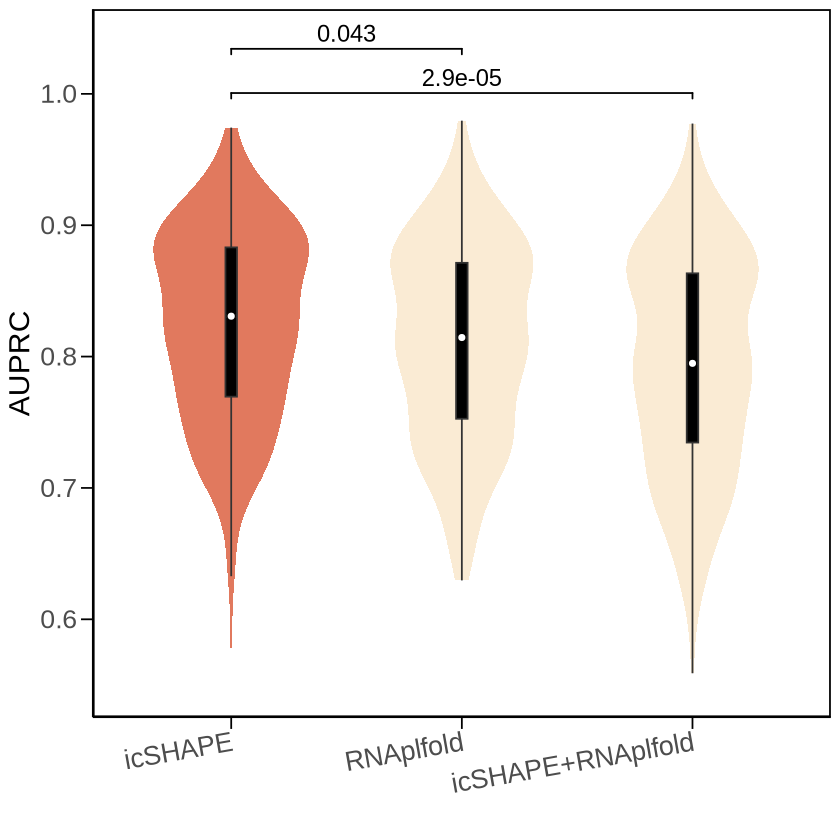

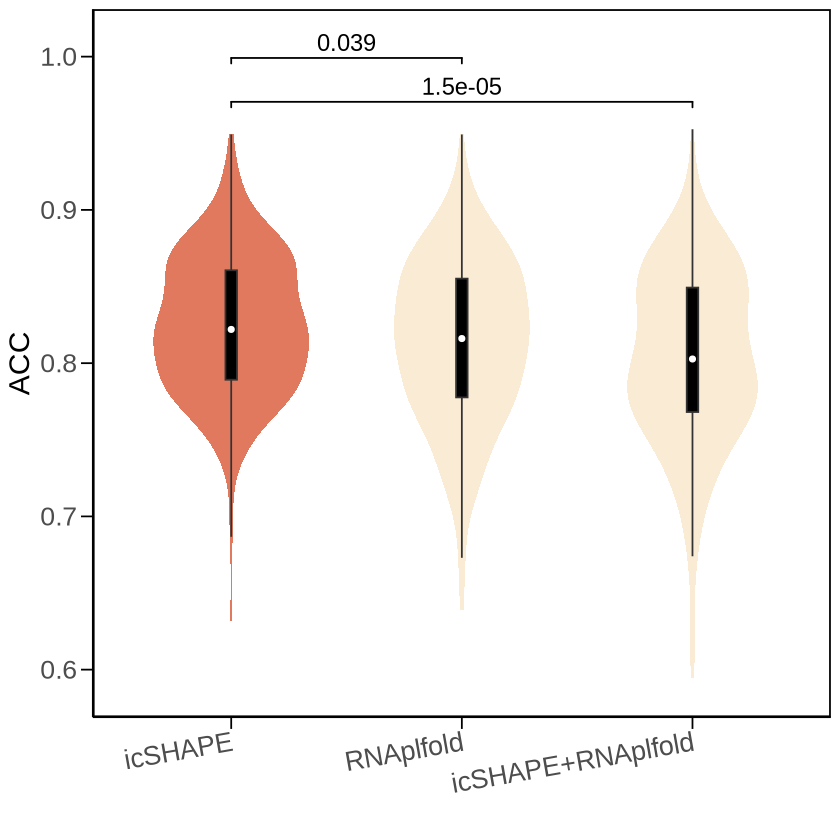

In [ ]:
# Batch generate ------------------------------------------------
cfg <- list(
  AUPRC = list(
    ylim = c(0.55, 1.04),
    filter = NULL,
    violin_adjust = 1,
    out = "violin_plot_AUPRC.pdf"
  ),
  ACC = list(
    ylim = c(0.59, 1.01),
    filter = function(x) x >= 0.54,
    violin_adjust = 1.25,
    out = "violin_plot_ACC.pdf"
  )
)

plots <- list()

for (m in names(cfg)) {
  long_df <- make_long_from_prefix(
    df,
    metric_prefix = m,
    value_filter  = cfg[[m]]$filter
  )
  
  p <- plot_violin_with_signif(
    long_df       = long_df,
    ylab          = m,
    ylim          = cfg[[m]]$ylim,
    fill_colors   = fill_colors,
    comparisons   = my_comparisons,
    step_increase = 0.08,
    textsize      = 5,
    violin_width  = 0.675,
    violin_adjust = cfg[[m]]$violin_adjust
  )
  
  plots[[m]] <- p
  print(p)
  
  ggsave(
    filename = file.path(out_dir, cfg[[m]]$out),
    plot = p, width = 6.5, height = 7, dpi = 300
  )
}
